# Visualise Exact-Search Results (ViT + FAISS)

This notebook shows, for a chosen query image:

1. the query image and its ViT embedding vector (the "vector input"),
2. the top-K images retrieved by FAISS `IndexFlatIP` exact search,
3. the cosine similarity score of every retrieved image.

Pipeline being visualised:

```text
query image -> ViT-B/16 -> 768-d vector (row in vit_embeddings.npy)
                                  |
all 123,403 images -> ViT -> FAISS IndexFlatIP exact cosine search
                                  |
                          top-10 image ids (predictions.json)
```

Required local files (see README.md steps 2 and 4):

- `data/circo/vit_embeddings.npy` - float32 matrix `(123403, 768)`, L2-normalized
- `data/circo/vit_image_ids.npy` - COCO image ids, row-aligned with the matrix
- `experiments/vit-coco-faiss/results/exact/predictions.json` - exact top-10 per query
- `data/circo/unlabeled2017/` - the COCO images

To visualise different queries: pick any id from `predictions.json`, put it in
`QUERY_IDS` below and re-run the cells.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Any ids present as keys in results/exact/predictions.json.
QUERY_IDS = [214377, 293114, 258634]
TOP_K = 10
SAVE_IMAGES = True

In [2]:
# Resolve the repo root whether the notebook runs from its own folder
# or from the repository root.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data" / "circo").exists():
    REPO_ROOT = REPO_ROOT.parent.parent

EMBEDDINGS_PATH = REPO_ROOT / "data" / "circo" / "vit_embeddings.npy"
IDS_PATH = REPO_ROOT / "data" / "circo" / "vit_image_ids.npy"
PREDICTIONS_PATH = (
    REPO_ROOT / "experiments" / "vit-coco-faiss" / "results" / "exact" / "predictions.json"
)
IMAGE_DIR = REPO_ROOT / "data" / "circo" / "unlabeled2017"
OUTPUT_DIR = (
    REPO_ROOT / "experiments" / "vit-coco-faiss" / "results" / "visual-checks"
)

embeddings = np.load(EMBEDDINGS_PATH, mmap_mode="r")
image_ids = np.load(IDS_PATH)
predictions = json.loads(PREDICTIONS_PATH.read_text())
row_of = {int(image_id): row for row, image_id in enumerate(image_ids)}

def to_coco_filename(image_id):
    # COCO filenames are 12-digit zero-padded ids, e.g. 000000214377.jpg
    return IMAGE_DIR / f"{int(image_id):012d}.jpg"

print("embeddings:", embeddings.shape, embeddings.dtype)
print("image ids:", image_ids.shape[0])
print("queries available in predictions.json:", len(predictions))

embeddings: (123403, 768) float32
image ids: 123403
queries available in predictions.json: 200


## 1. The query: image and its vector input

The query image was converted to a 768-number ViT vector before searching.
Its vector is one row of `vit_embeddings.npy`. Because the vectors are
L2-normalized, the vector length (norm) is approximately 1.0.

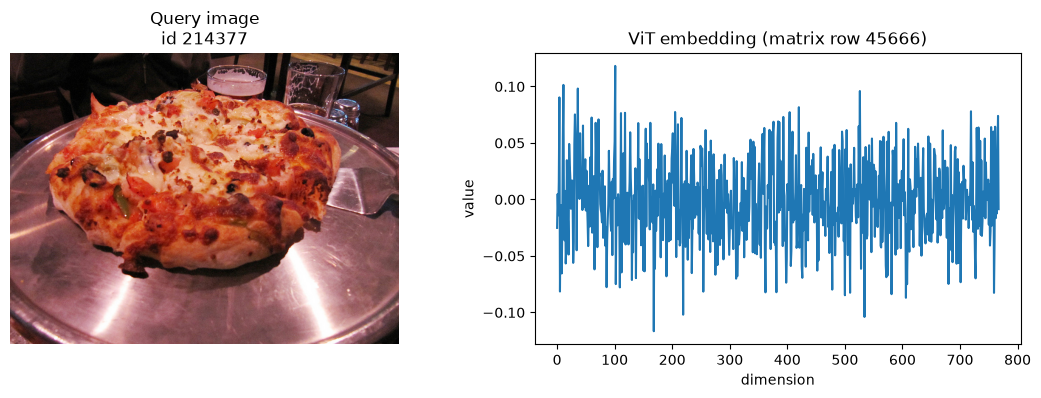

vector shape: (768,)
first 10 values: [-0.0252  0.0049 -0.014   0.0155  0.0904 -0.0815 -0.0143 -0.0052 -0.0655
 -0.0279]
norm (should be ~1.0): 1.0


In [3]:
def describe_query(query_id):
    row = row_of[int(query_id)]
    vector = np.asarray(embeddings[row])
    image = Image.open(to_coco_filename(query_id)).convert("RGB")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].imshow(image)
    axes[0].set_title(f"Query image\nid {query_id}")
    axes[0].axis("off")
    axes[1].plot(vector)
    axes[1].set_title(f"ViT embedding (matrix row {row})")
    axes[1].set_xlabel("dimension")
    axes[1].set_ylabel("value")
    plt.tight_layout()
    plt.show()

    print("vector shape:", vector.shape)
    print("first 10 values:", np.round(vector[:10], 4))
    print("norm (should be ~1.0):", round(float(np.linalg.norm(vector)), 4))

describe_query(QUERY_IDS[0])

## 2. Recalculating similarity scores

`predictions.json` stores the top-10 result ids in rank order but not the
scores. Since all vectors are L2-normalized, the cosine similarity of the
query and any result is simply their dot product:

In [4]:
def scores_for(query_id, result_ids):
    query_vector = np.asarray(embeddings[row_of[int(query_id)]])
    result_rows = [row_of[int(rid)] for rid in result_ids]
    result_vectors = np.asarray(embeddings[result_rows])
    # L2-normalized vectors: dot product == cosine similarity.
    return result_vectors @ query_vector

## 3. Result grid

Layout: query plus ranks 1-5 on the first row, ranks 6-10 on the second.
Each result is labelled with its rank, COCO image id and cosine score.
Grids are saved to `results/visual-checks/`.

saved: experiments/vit-coco-faiss/results/visual-checks/query_214377_top10.png


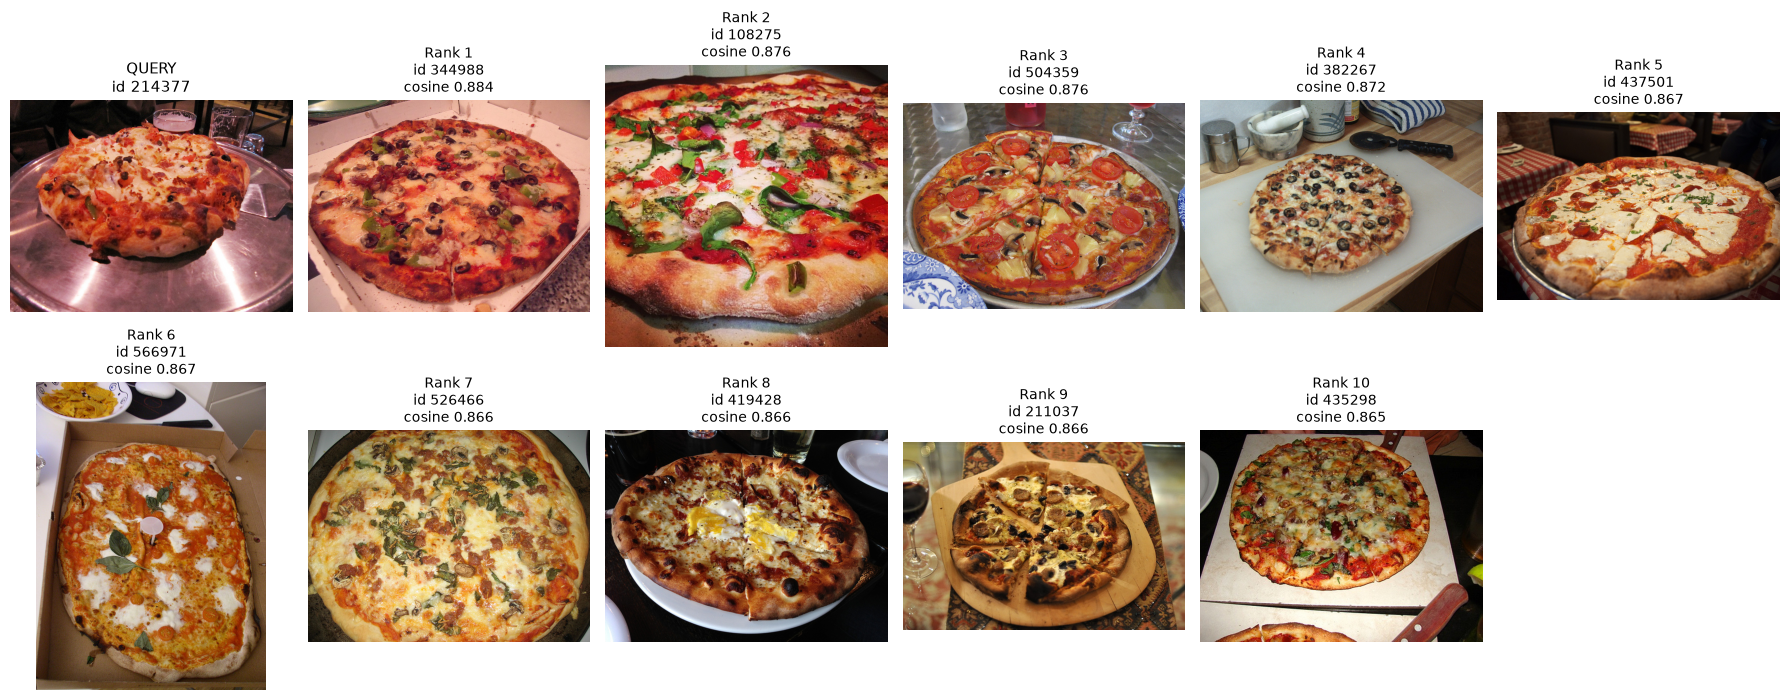

saved: experiments/vit-coco-faiss/results/visual-checks/query_293114_top10.png


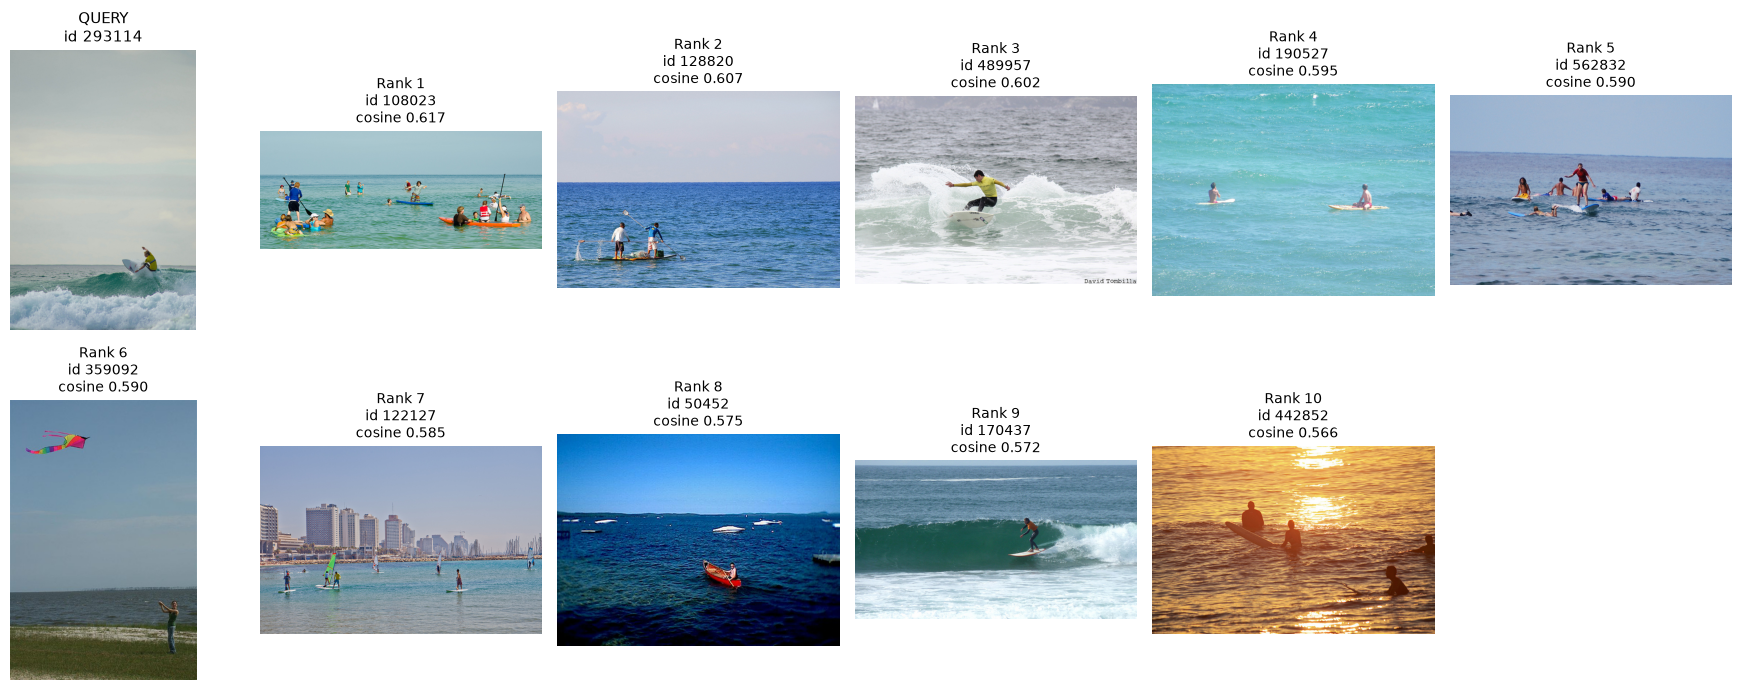

saved: experiments/vit-coco-faiss/results/visual-checks/query_258634_top10.png


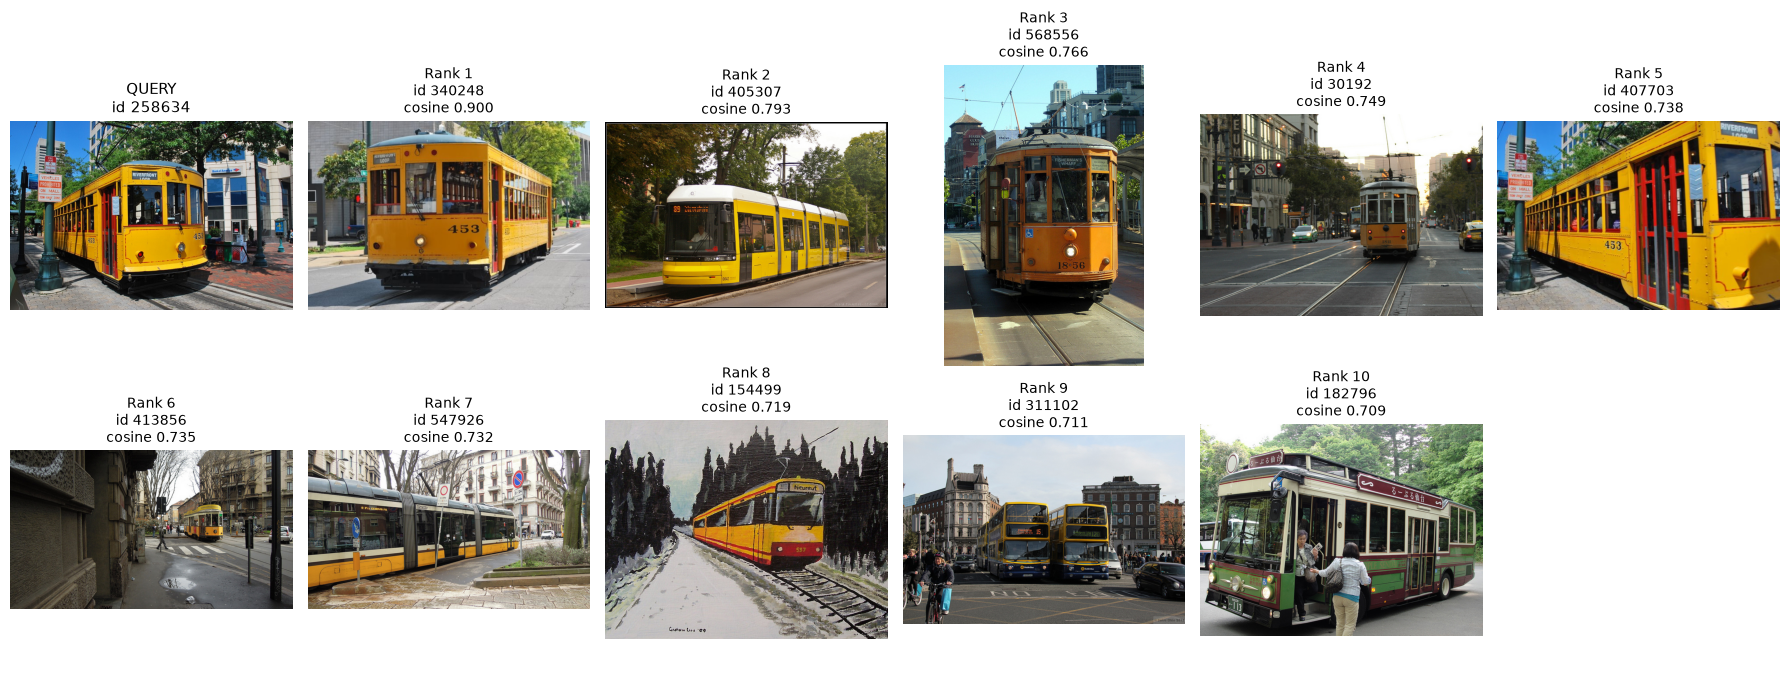

In [5]:
def show_results(query_id):
    result_ids = predictions[str(query_id)][:TOP_K]
    scores = scores_for(query_id, result_ids)

    fig, axes = plt.subplots(2, 6, figsize=(18, 7))
    axes = axes.ravel()

    axes[0].imshow(Image.open(to_coco_filename(query_id)).convert("RGB"))
    axes[0].set_title(f"QUERY\nid {query_id}", fontsize=11)
    axes[0].axis("off")

    for position, (result_id, score) in enumerate(zip(result_ids, scores), start=1):
        axes[position].imshow(Image.open(to_coco_filename(result_id)).convert("RGB"))
        axes[position].set_title(
            f"Rank {position}\nid {result_id}\ncosine {score:.3f}", fontsize=10
        )
        axes[position].axis("off")

    for position in range(1 + len(result_ids), len(axes)):
        axes[position].axis("off")

    plt.tight_layout()
    if SAVE_IMAGES:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        out_path = OUTPUT_DIR / f"query_{query_id}_top{TOP_K}.png"
        plt.savefig(out_path, dpi=120, bbox_inches="tight")
        print("saved:", out_path.relative_to(REPO_ROOT))
    plt.show()

for query_id in QUERY_IDS:
    show_results(query_id)

## 4. Sanity checks

For every visualised query: the query is not returned as its own result, all
result ids exist in the embedding matrix, all image files exist, exactly
`TOP_K` results are present, and scores are in descending order.

In [6]:
def validate(query_id):
    result_ids = predictions[str(query_id)][:TOP_K]
    scores = scores_for(query_id, result_ids)
    assert int(query_id) not in [int(r) for r in result_ids], "query returned its own image"
    assert all(int(r) in row_of for r in result_ids), "result id missing from embeddings"
    assert all(to_coco_filename(r).exists() for r in result_ids), "result image file missing"
    assert len(result_ids) == TOP_K, "unexpected result count"
    assert np.all(np.diff(scores) <= 1e-9), "scores are not in descending order"
    print(f"query {query_id}: OK ({len(result_ids)} results, top cosine {scores[0]:.3f})")

for query_id in QUERY_IDS:
    validate(query_id)
print("ALL CHECKS PASSED")

query 214377: OK (10 results, top cosine 0.884)
query 293114: OK (10 results, top cosine 0.617)
query 258634: OK (10 results, top cosine 0.900)
ALL CHECKS PASSED


## How to visualise other queries

1. Open `results/exact/predictions.json` and copy any key (a query image id).
2. Put it into `QUERY_IDS` in the configuration cell.
3. Run all cells again.

The notebook only needs the embeddings, the image ids, `predictions.json`
and the COCO images - it does not re-run FAISS or ViT.